In [1]:
import numpy as np
import matplotlib.pyplot as plt
from operator import itemgetter

%matplotlib inline
%load_ext autoreload
%autoreload 2

## Toy simulator

Simulates a point source population on top of an isotropic background.

In [39]:
from scipy.stats import binned_statistic_2d
from astropy.convolution import convolve, Gaussian2DKernel
from scipy.stats import norm

t_min = -1  # Coordinate boundaries
t_max = 1
n_t = 64  # Number of pixels
counts_min = 2  # Minimum and maximum counts emitted by each PS
counts_max = 2
fwhm_psf = 0.5  # FWHM of Gaussian PSF

# Pixel binning
pixel_size = (t_max - t_min) / n_t
bins = np.linspace(t_min, t_max, n_t + 1)

# PSF stuff
sigma_psf = fwhm_psf / 2 ** 1.5 * np.sqrt(np.log(2))  # Convert FWHM to standard deviation
kernel = Gaussian2DKernel(x_stddev=1.0 * sigma_psf / pixel_size)

def simulate(plot=False, poiss_fluctuate=False):
    
    mu_iso = np.random.uniform(0, 10)
    
    mu_ps_iso = np.random.uniform(0, 200)
    n_ps_iso = np.random.poisson(mu_ps_iso)
    
    # Draw position of PSs and their counts
    z_x_iso = np.random.uniform(t_min, t_max, size=(2, n_ps_iso))
    z_c_iso = np.random.uniform(counts_min, counts_max, n_ps_iso)
    
    mu_ps_csp = np.random.uniform(0, 10)
    n_ps_csp = 0  # np.random.poisson(mu_ps_csp)
    
    # Draw position of PSs and their counts
    z_x_csp = norm.rvs(loc=0, scale=0.5, size=(2, n_ps_csp)) 
    z_c_csp = np.random.uniform(counts_min, counts_max, n_ps_csp)
    
    mu_iso_map = mu_iso * np.ones((n_t, n_t))

    if n_ps_iso > 0:
        mu_signal_iso = binned_statistic_2d(x=z_x_iso[0], y=z_x_iso[1], values=z_c_iso, statistic='sum', bins=bins).statistic
    else:
        mu_signal_iso = np.zeros_like(mu_iso_map)
        
    if n_ps_csp > 0:
        mu_signal_csp = binned_statistic_2d(x=z_x_csp[0], y=z_x_csp[1], values=z_c_csp, statistic='sum', bins=bins).statistic
    else:
        mu_signal_csp =  np.zeros_like(mu_iso_map)
        
    counts_binned = (mu_iso_map + convolve(mu_signal_iso, kernel) + convolve(mu_signal_csp, kernel))

    if poiss_fluctuate:
        counts_binned = np.random.poisson(counts_binned)

    if plot:
        plt.imshow(counts_binned)
    
    return mu_ps_iso, counts_binned
#     return mu_ps_iso, mu_ps_csp, mu_iso, counts_binned

In [40]:
# from scipy.stats import binned_statistic_2d
# from astropy.convolution import convolve, Gaussian2DKernel
# from scipy.stats import norm

# t_min = -1  # Coordinate boundaries
# t_max = 1
# n_t = 64  # Number of pixels
# counts_min = 100  # Minimum and maximum counts emitted by each PS
# counts_max = 100
# fwhm_psf = 1.  # FWHM of Gaussian PSF

# # Pixel binning
# pixel_size = (t_max - t_min) / n_t
# bins = np.linspace(t_min, t_max, n_t + 1)

# # PSF stuff
# sigma_psf = fwhm_psf / 2 ** 1.5 * np.sqrt(np.log(2))  # Convert FWHM to standard deviation
# kernel = Gaussian2DKernel(x_stddev=1.0 * sigma_psf / pixel_size)

# def simulate(plot=False):
    
#     mu_iso = 5
    
#     mu_ps_iso = 1.
#     n_ps_iso = 1
    
#     # Draw position of PSs and their counts
#     z_x_iso = np.random.uniform(t_min, t_max, size=(2, n_ps_iso))
#     z_c_iso = np.random.uniform(counts_min, counts_max, n_ps_iso)
    
#     mu_iso_map = mu_iso * np.ones((n_t, n_t))

#     if n_ps_iso > 0:
#         mu_signal_iso = binned_statistic_2d(x=z_x_iso[0], y=z_x_iso[1], values=z_c_iso, statistic='sum', bins=bins).statistic
#     else:
#         mu_signal_iso = np.zeros_like(mu_iso_map)
        
        
#     counts_binned = (mu_iso_map + convolve(mu_signal_iso, kernel))

#     if plot:
#         plt.imshow(counts_binned)
    
#     return mu_ps_iso, counts_binned

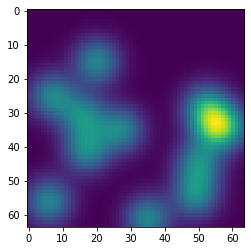

In [60]:
_, x = simulate(plot=True)

In [38]:
import sys
sys.path.append("../")

import torch
from pytorch_lightning import LightningModule, Trainer, seed_everything
from torch import nn
from torch.nn import functional as F

from models.resnet_ed import (
    resnet18_decoder,
    resnet18_encoder,
    resnet50_decoder,
    resnet50_encoder,
)

In [6]:
import torch
import torch.nn as nn

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor, EarlyStopping, StochasticWeightAveraging
from pytorch_lightning.loggers import MLFlowLogger

from torch.utils.data import TensorDataset, DataLoader, random_split, SubsetRandomSampler

In [7]:
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.encode = nn.Sequential(nn.Conv2d(1, 64, 4, 2, 1), 
                                    nn.LeakyReLU(0.2, inplace = True), 
                                    nn.Conv2d(64, 128, 4, 2, 1), 
                                    nn.BatchNorm2d(128), 
                                    nn.LeakyReLU(0.2, inplace = True), 
                                    nn.Conv2d(128, 256, 4, 2, 1), 
                                    nn.BatchNorm2d(256), 
                                    nn.LeakyReLU(0.2, inplace = True), 
                                    nn.Conv2d(256, 512, 4, 2, 1), 
                                    nn.BatchNorm2d(512), 
                                    nn.LeakyReLU(0.2, inplace = True), 
                                    nn.Conv2d(512, 2048, 4, 1, 0), 
                                    nn.LeakyReLU(0.2, inplace = True)
                                   )        
    def forward(self, x):
        return self.encode(x).view(x.size(0), -1)

class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.decode = nn.Sequential(nn.ConvTranspose2d(256, 512, 4, 1, 0), 
                                    nn.BatchNorm2d(512), 
                                    nn.ReLU(inplace = True), 
                                    nn.ConvTranspose2d(512, 256, 4, 2, 1), 
                                    nn.BatchNorm2d(256), 
                                    nn.ReLU(inplace = True),                                    
                                    nn.ConvTranspose2d(256, 128, 4, 2, 1), 
                                    nn.BatchNorm2d(128), 
                                    nn.ReLU(inplace = True),                                    
                                    nn.ConvTranspose2d(128, 64, 4, 2, 1), 
                                    nn.BatchNorm2d(64), 
                                    nn.ReLU(inplace = True),                                    
                                    nn.ConvTranspose2d(64, 1, 4, 2, 1), 
                                    nn.Tanh()                                    
                                   )        
    def forward(self, z):
        x = z.view(z.size(0), 256, 1, 1) 
        return self.decode(x)


In [78]:
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.encode = nn.Sequential(nn.Linear(64 * 64, 512), 
                                    nn.LeakyReLU(0.2, inplace = True), 
                                    nn.Linear(512, 256), 
                                    nn.LeakyReLU(0.2, inplace = True), 
                                   )        
    def forward(self, x):
        return self.encode(x.view(x.size(0), -1))

class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.decode = nn.Sequential(nn.Linear(64, 256), 
                                    nn.LeakyReLU(0.2, inplace = True), 
                                    nn.Linear(256, 512), 
                                    nn.LeakyReLU(0.2, inplace = True), 
                                    nn.Linear(512, 64 * 64), 
                                    nn.Tanh()                                    
                                   )        
    def forward(self, z):
        return self.decode(z).view(z.size(0), 1, 64, 64) 


In [79]:
class VAE(LightningModule):
    """Standard VAE with Gaussian Prior and approx posterior.
    Model is available pretrained on different datasets:
    Example::
        # not pretrained
        vae = VAE()
        # pretrained on cifar10
        vae = VAE(input_height=32).from_pretrained('cifar10-resnet18')
        # pretrained on stl10
        vae = VAE(input_height=32).from_pretrained('stl10-resnet18')
    """

    def __init__(
        self,
        enc_out_dim: int = 256,
        latent_dim: int = 64,
        lr: float = 1e-4,
        **kwargs,
    ):
        """
        Args:
            input_height: height of the images
            enc_type: option between resnet18 or resnet50
            first_conv: use standard kernel_size 7, stride 2 at start or
                replace it with kernel_size 3, stride 1 conv
            maxpool1: use standard maxpool to reduce spatial dim of feat by a factor of 2
            enc_out_dim: set according to the out_channel count of
                encoder used (512 for resnet18, 2048 for resnet50)
            kl_coeff: coefficient for kl term of the loss
            latent_dim: dim of latent space
            lr: learning rate for Adam
        """

        super().__init__()

        self.save_hyperparameters()

        self.lr = lr
        self.enc_out_dim = enc_out_dim
        self.latent_dim = latent_dim

        self.encoder = Encoder()
        self.decoder = Decoder()
        
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau
        self.scheduler_kwargs = {"patience":5}

        self.fc_mu = nn.Linear(self.enc_out_dim, self.latent_dim)
        self.fc_var = nn.Linear(self.enc_out_dim, self.latent_dim)
        
        self.kll = []
        self.rl = []
        
    def forward(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x)
        log_var = self.fc_var(x)
        p, q, z = self.sample(mu, log_var)
        return self.decoder(z)

    def _run_step(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x)
        log_var = self.fc_var(x)
        p, q, z = self.sample(mu, log_var)
        return z, self.decoder(z), p, q

    def sample(self, mu, log_var):
        std = torch.exp(log_var / 2)
        p = torch.distributions.Normal(torch.zeros_like(mu), torch.ones_like(std))
        q = torch.distributions.Normal(mu, std)
        z = q.rsample()
        return p, q, z

    def step(self, batch, batch_idx):
        x, y = batch
        z, x_hat, p, q = self._run_step(x)

        recon_loss = F.mse_loss(x_hat, x, reduction="mean")

        kl = torch.distributions.kl_divergence(q, p)
        kl = kl.mean()

        loss = kl + 5 * recon_loss
        
        self.kll.append(kl)
        self.rl.append(recon_loss)

        logs = {
            "recon_loss": recon_loss,
            "kl": kl,
            "loss": loss,
        }
        return loss, logs

    def training_step(self, batch, batch_idx):
        loss, logs = self.step(batch, batch_idx)
        self.log_dict({f"train_{k}": v for k, v in logs.items()}, on_step=True, on_epoch=False)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, logs = self.step(batch, batch_idx)
        self.log_dict({f"val_{k}": v for k, v in logs.items()})
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-5)
        
        return {"optimizer": optimizer, 
                    "lr_scheduler": {
                    "scheduler": self.scheduler(optimizer, **self.scheduler_kwargs),
                    "interval": "epoch",
                    "monitor": "val_loss",
                    "frequency": 1}
                }


In [80]:
model = VAE()

In [11]:
from tqdm.notebook import tqdm
simulations = [simulate() for _ in tqdm(range(20000))]

  0%|          | 0/20000 [00:00<?, ?it/s]

In [12]:
x = list(map(itemgetter(1), simulations))
mu_ps_iso = list(map(itemgetter(0), simulations))
# mu_ps_csp = list(map(itemgetter(1), simulations))
# mu_iso = list(map(itemgetter(2), simulations))

In [13]:
x = torch.Tensor(np.array(x)).unsqueeze(1)
y = torch.Tensor(np.array([mu_ps_iso])).T

In [14]:
x_std = x.std(axis=0)
x_mean = x.mean(axis=0)
x = (x - x_mean) / x_std

y_std = y.std(axis=0)
y_mean = y.mean(axis=0)
y = (y - y_mean) / y_std

In [15]:
# import torchvision
# import torchvision.transforms as transforms

# data_transform = transforms.Compose([
#                 transforms.ToTensor()
#         ])
# dataset = torchvision.datasets.MNIST('.', transform=data_transform, download=False)

# val_fraction = 0.
# n_samples_val = int(val_fraction * len(dataset))

# dataset_train, dataset_val = random_split(dataset, [len(dataset) - n_samples_val, n_samples_val])
# train_loader = DataLoader(dataset_train, batch_size=64, num_workers=8, shuffle=True)
# val_loader = DataLoader(dataset_val, batch_size=64, num_workers=8, shuffle=False)

In [73]:
val_fraction = 0.1
n_samples_val = int(val_fraction * len(x))

dataset = TensorDataset(x, y)

dataset_train, dataset_val = random_split(dataset, [len(x) - n_samples_val, n_samples_val])
train_loader = DataLoader(dataset_train, batch_size=64, num_workers=8, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=64, num_workers=8, shuffle=False)

/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/torch/utils/data/dataloader.py:478: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [81]:
checkpoint_callback = ModelCheckpoint(monitor="val_loss")
early_stop_callback = EarlyStopping(monitor='val_loss', patience=8)        
lr_monitor = LearningRateMonitor(logging_interval='epoch')

trainer = pl.Trainer(max_epochs=100, gpus=1, gradient_clip_val=0.5, callbacks=[checkpoint_callback, early_stop_callback, lr_monitor])
trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=val_loader)
model.load_from_checkpoint(checkpoint_callback.best_model_path);

GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Set SLURM handle signals.

  | Name    | Type    | Params
------------------------------------
0 | encoder | Encoder | 2.2 M 
1 | decoder | Decoder | 2.2 M 
2 | fc_mu   | Linear  | 16.4 K
3 | fc_var  | Linear  | 16.4 K
------------------------------------
4.5 M     Trainable params
0         Non-trainable params
4.5 M     Total params
18.045    Total estimated model params size (MB)


Validation sanity check: 0it [00:00, ?it/s]

Training: -1it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

...

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/pytorch_lightning/trainer/trainer.py:1051: UserWarning: Detected KeyboardInterrupt, attempting graceful shutdown...
  rank_zero_warn("Detected KeyboardInterrupt, attempting graceful shutdown...")


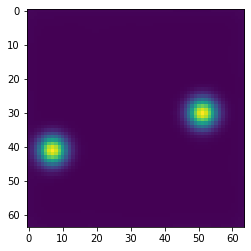

In [89]:
n_i = 11
plt.imshow(dataset_train[n_i][0][0])

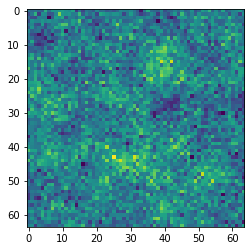

In [91]:
x_dec = model.to('cuda')(dataset_train[n_i][0].unsqueeze(1).to('cuda')).to('cpu')
plt.imshow(x_dec.detach().numpy()[0,0])

In [59]:
# model.to('cpu')

# mu = torch.zeros(1, 256)
# log_var = torch.ones(1, 256)

# p, q, z = model.sample(mu, log_var)
# im = model.decoder(z)
# plt.imshow(im[0,0].detach().numpy())

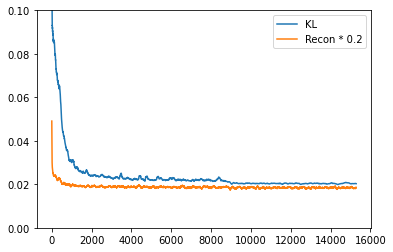

In [43]:
plt.plot(running_mean([loss.cpu().detach().numpy() for loss in model.kll], 100), label="KL")
plt.plot(running_mean([0.2 * loss.cpu().detach().numpy() for loss in model.rl], 100), label="Recon * 0.2")

plt.ylim(0, 0.1)
plt.legend()

In [42]:
def running_mean(x, N):
    cumsum = np.cumsum(np.insert(x, 0, 0)) 
    return (cumsum[N:] - cumsum[:-N]) / float(N)
